                           Assignment - 1
**IPL Data Analysis**

 Objective:

This assignment analyzes IPL match data from 2008-2019 to identify patterns in team
performance, match outcomes, player contributions, and venue influence. The goal is to
extract meaningful insights that help understand key factors affecting match results in
the Indian Premier League

Methodology:

-In this project, IPL data from 2008–2019 was analyzed using Python. First, the datasets were loaded and explored to understand the structure of the data.

-Missing values and unnecessary columns were handled during the data cleaning stage.After cleaning the data, different analysis techniques were applied to answer the business questions provided in the assignment.

-Various visualizations such as bar charts and line charts were created to understand patterns in team performance, venue distribution, toss decisions, and player contributions.

The analysis helped identify important insights about match results, team success, and player performance in the IPL.

Tools and Technologies Used:

• Python - Used as the main programming language for data analysis.
• Pandas - Used for loading, cleaning, and analyzing the dataset.
• NumPy - Used for basic numerical operations.
• Matplotlib - Used to create charts and visualizations.
• Seaborn - Used for better statistical visualizations.
• Google Colab / Jupyter Notebook - Used as the environment to run the Python code and perform the analysis.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [33]:
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

In [34]:
print("Matches shape", matches.shape)
print("Deliveries shape", deliveries.shape)

Matches shape (756, 18)
Deliveries shape (179078, 21)


In [35]:
matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [36]:
deliveries.head()


,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


**Datasets Description-**

The above two datasets contains two csv format files that consists the data regarding the IPL matches and Ball- by- ball deliveries in matches from year 2008- 2019.



*   matches.csv- This dataset contains the information regarding the matches yearwise, toss results, teams, venue, player of the match.

*   deliveries.csv- This dataset consists of the ball- by- ball deliveries held in the matches such as bowler, runs scored, batsman, information of innings, non- strikers and overs.

The two datasets provides the depth match-level as well as player- level performance of the matches, enabling us to visualise the insights of team strategies and match outcomes.







In [37]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   season           756 non-null    int64 
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3          119 non-null    ob

In [38]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179078 entries, 0 to 179077
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          179078 non-null  int64 
 1   inning            179078 non-null  int64 
 2   batting_team      179078 non-null  object
 3   bowling_team      179078 non-null  object
 4   over              179078 non-null  int64 
 5   ball              179078 non-null  int64 
 6   batsman           179078 non-null  object
 7   non_striker       179078 non-null  object
 8   bowler            179078 non-null  object
 9   is_super_over     179078 non-null  int64 
 10  wide_runs         179078 non-null  int64 
 11  bye_runs          179078 non-null  int64 
 12  legbye_runs       179078 non-null  int64 
 13  noball_runs       179078 non-null  int64 
 14  penalty_runs      179078 non-null  int64 
 15  batsman_runs      179078 non-null  int64 
 16  extra_runs        179078 non-null  int

In [39]:
matches.isnull().sum()

,0
id,0
season,0
city,7
date,0
team1,0
team2,0
toss_winner,0
toss_decision,0
result,0
dl_applied,0


In [40]:
deliveries.isnull().sum()

,0
match_id,0
inning,0
batting_team,0
bowling_team,0
over,0
ball,0
batsman,0
non_striker,0
bowler,0
is_super_over,0


In [41]:
matches['date'] = pd.to_datetime(matches['date'], format='mixed', dayfirst=True)

In [42]:
matches['date'].head()

,date
0,2017-04-05
1,2017-04-06
2,2017-04-07
3,2017-04-08
4,2017-04-08


In [43]:
#Summary: Dataset
print("Total Matches played:", matches.shape[0])
print("Total Deliveries Bowled:", deliveries.shape[0])
print("Total Seasons:", matches['season'].nunique())
print("Total Teams:", matches['team1'].nunique())
print("Total Venues:", matches['venue'].nunique())





Total Matches played: 756
Total Deliveries Bowled: 179078
Total Seasons: 12
Total Teams: 15
Total Venues: 41


Data cleaning is performed before the analysis of data by handling the missing or null values, by removing or filtering the unwanted columns and the data which is not needed so that the data could analysed more accurately.

In [44]:
# Data Cleaning
matches['win_by_runs'] = matches['win_by_runs'].fillna(0)
matches['win_by_wickets'] = matches['win_by_wickets'].fillna(0)

matches['winner'] = matches['winner'].fillna("No Result")
matches['player_of_match'] = matches['player_of_match'].fillna("Unknown")
matches['city'] = matches['city'].fillna("Unknown")
matches['umpire1'] = matches['umpire1'].fillna("Unknown")
matches['umpire2'] = matches['umpire2'].fillna("Unknown")

# Check if 'umpire3' column exists before dropping
if 'umpire3' in matches.columns:
    matches.drop(columns=['umpire3'], inplace=True)

matches['date'] = pd.to_datetime(matches['date'], format='mixed', dayfirst=True)

**Business Oriented Analysis Questions-**

**Q.1** Match won by maximim margin of runs.

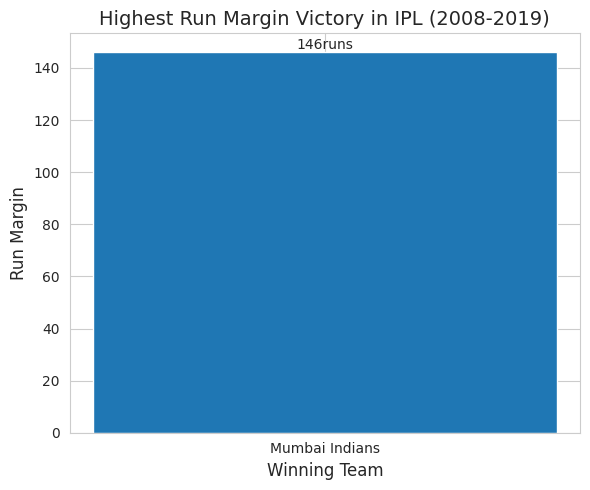

In [45]:
max_run = matches.loc[matches['win_by_runs'].idxmax()]
plt.figure(figsize=(6,5))
plt.bar(max_run['winner'], max_run['win_by_runs'])
plt.title("Highest Run Margin Victory in IPL (2008-2019)")
plt.xlabel("Winning Team")
plt.ylabel("Run Margin")
plt.text(
    0,
    max_run['win_by_runs'],
    str(max_run['win_by_runs']) + "runs",
    ha='center',
    va='bottom')
plt.tight_layout()
plt.show()



**Insight**

*  The graph shows a 146 run margin, which is extremely huge in T20 cricket.
* Mumbai Indians won the match by 146 runs, which reflects an extremely dominant performance.
* The graph represents that the winning team dominated the match completely both in batting as well as batting.





**Q.2** Match won by maximum wickets.

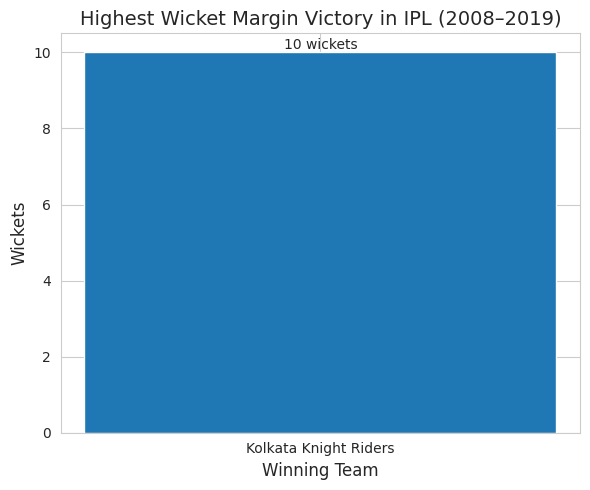

In [46]:
max_wicket = matches.loc[matches['win_by_wickets'].idxmax()]
plt.figure(figsize=(6,5))
plt.bar(max_wicket['winner'], max_wicket['win_by_wickets'])
plt.title("Highest Wicket Margin Victory in IPL (2008–2019)")
plt.xlabel("Winning Team")
plt.ylabel("Wickets")
plt.text(
0,
max_wicket['win_by_wickets'],
str(max_wicket['win_by_wickets']) + " wickets",
ha='center',
va='bottom')
plt.tight_layout()
plt.show()

**Insights-**

* Shows that Kolkata Knight Riders achieved the highest wicket- margin victory.
* The data shows their continous victory on the other team with ongoing years.
*   The team won by 10 wickets and showed the hiking victory and it's dominanace over the other team.






**Q.3** Match won by the minimum margin of runs.

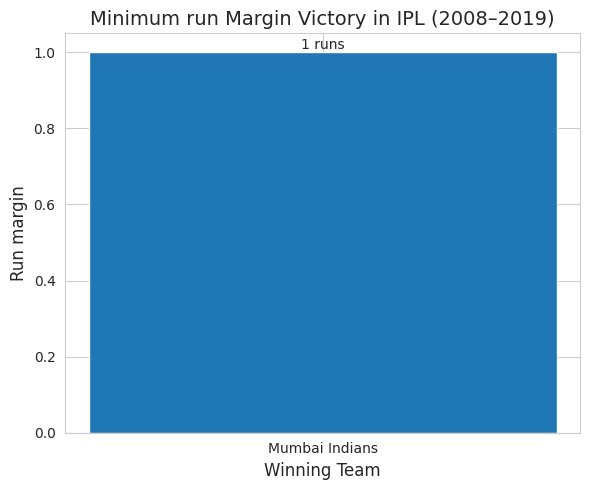

In [47]:
run_matches = matches[matches['win_by_runs'] > 0]
min_run_match = run_matches.loc[run_matches['win_by_runs'].idxmin()]
plt.figure(figsize=(6,5))
plt.bar(min_run_match['winner'], min_run_match['win_by_runs'])
plt.title("Minimum run Margin Victory in IPL (2008–2019)")
plt.xlabel("Winning Team")
plt.ylabel("Run margin")
plt.text(
0,
min_run_match['win_by_runs'],
str(min_run_match['win_by_runs']) + " runs",
ha='center',
va='bottom')
plt.tight_layout()
plt.show()

**Insights-**

*  The graph shows the run margin shown is 1.
This shows that the winning team won by just 1 run which is closest possible win in the cricket.
*  Both the teams performed at a very similar level, that made the fans' prediction confusing.
* This also shows that how competitive IPL could be where even a single run can decide the game changing outcome.






**Q.4** Match won by minimum wickets.

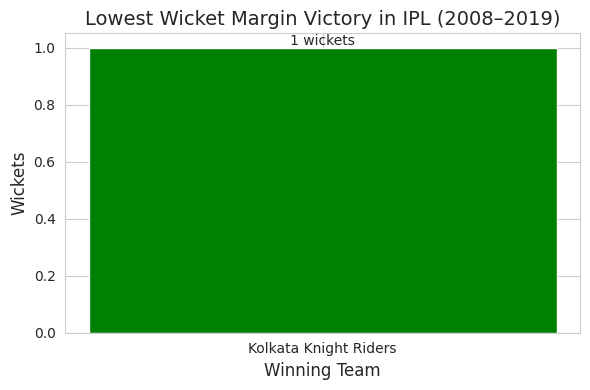

In [48]:
wicket_matches = matches[matches['win_by_wickets'] > 0]
min_wicket_match = wicket_matches.loc[wicket_matches['win_by_wickets'].idxmin()]
plt.figure(figsize=(6,4))
plt.bar(min_wicket_match['winner'],
min_wicket_match['win_by_wickets'], color= 'g')
plt.title("Lowest Wicket Margin Victory in IPL (2008–2019)")
plt.xlabel("Winning Team")
plt.ylabel("Wickets")
plt.text(0,
min_wicket_match['win_by_wickets'],
str(min_wicket_match['win_by_wickets']) + " wickets",
ha='center',
va='bottom')
plt.tight_layout()
plt.show()

**Insights-**

*  The lowest wicket margin shown is 1 which shows the winning team had only one wicket left when they completed the run chase.
* The graph shows the Kolkata Knight Riders as the winning team, this indicates that they managed to win a match in a very tight situation.
* This also shows the unpredictable 1-wicket victory of T20 cricket matches.
* One more conclusion that can be drawn is by observing that the chasing team still had the chances to win even after the fall of 9 wickets.





**Q.5** Matches where D/L method was and wasn't applied.

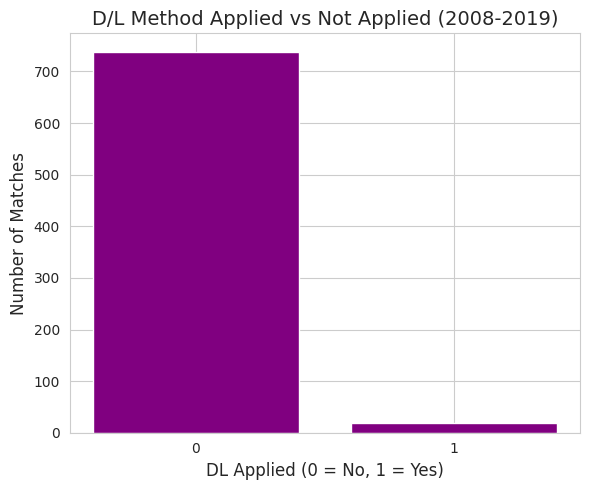

In [49]:
dl_counts = matches['dl_applied'].value_counts()
plt.figure(figsize=(6,5))
plt.bar(dl_counts.index.astype(str),
dl_counts.values,color='purple')
plt.title("D/L Method Applied vs Not Applied (2008-2019)")
plt.xlabel("DL Applied (0 = No, 1 = Yes)")
plt.ylabel("Number of Matches")
plt.tight_layout()
plt.show()

**Insights-**

*   The graph for 0 D/L not applied has extremely high around 700+ matches.
*   This means that the most of the IPL matches were conducted without any obstacle such as rain.
*   However, the graph for D/L applied is very small and less that shows that only a small number of matches required the Duckworth-Lewis method.
* One thing that can be drawn from this outcome is that it shows that most of the IPL matches are held in the nominal period that caused very less chances of interruptions.





**Q.6** No. of matches held in each city.

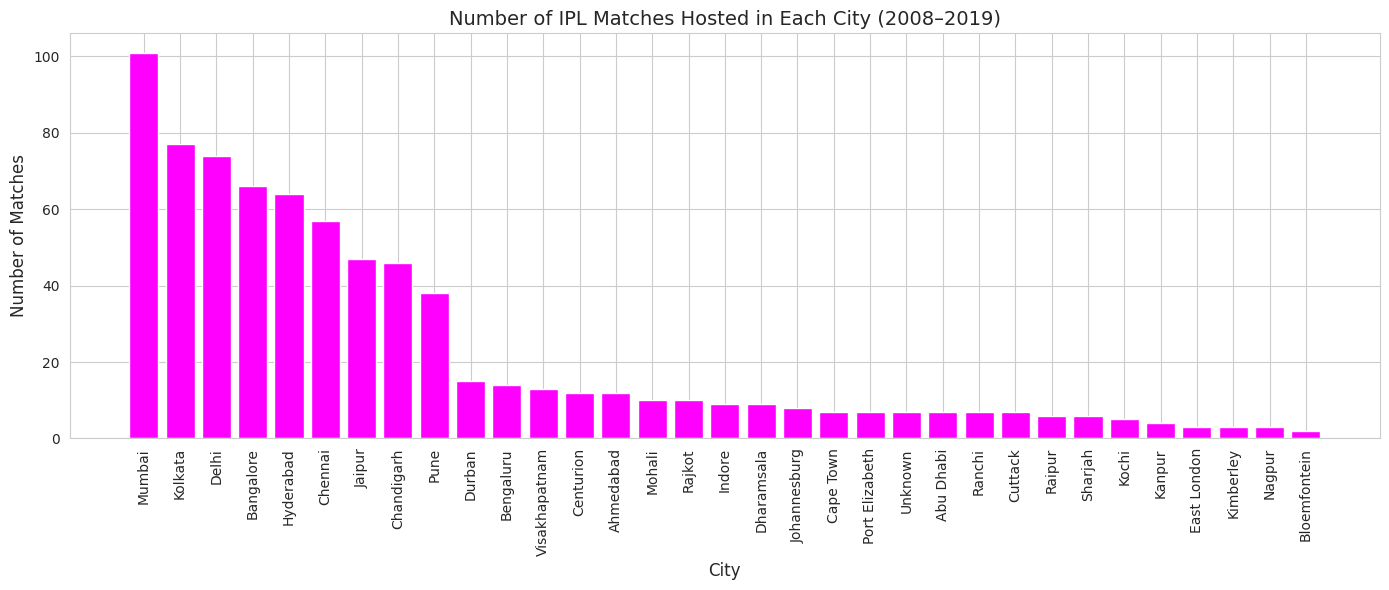

In [50]:
city_counts = matches['city'].value_counts()
plt.figure(figsize=(14,6))
plt.bar(city_counts.index, city_counts.values,color='magenta')
plt.title("Number of IPL Matches Hosted in Each City (2008–2019)")
plt.xlabel("City")
plt.ylabel("Number of Matches")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Insights-**

* The graph clearly shows that Mumbai leads by a large margin, showing it's importace in IPL history.
* This also indicates that only few cities around 5-6 hosts the majority of matches while the rest host very few.

* Cities that can be considered as the most long-term IPL fanchises could be-
- Mumbai Indians
- Chennai Super Kings
- Kolkata Knight Riders

* Cities such as Jaipur, Chnadigarh, and Pune hsoted a moderate number of matches.
* Also indicates the IPL's attempt to expand it's global audience in regions like the Middle East.








**Q.7**No. of matches won by each team.

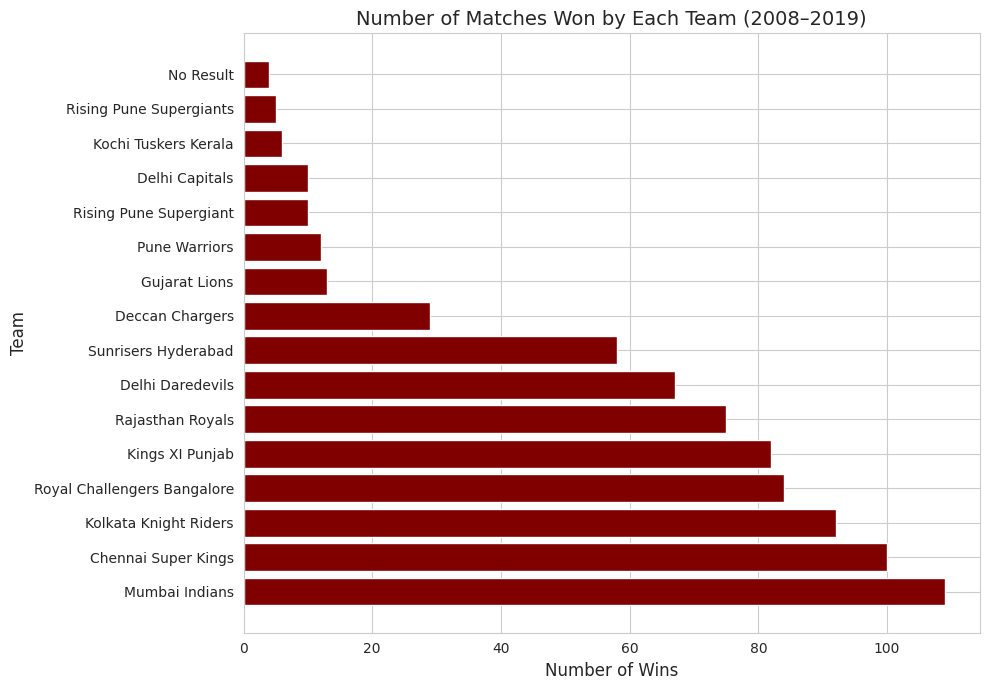

In [51]:
team_won = matches['winner'].value_counts()
plt.figure(figsize=(10,7))
plt.xlabel("Number of Wins")
plt.ylabel("Team")
plt.barh(team_won.index,
team_won.values, color='maroon')
plt.title("Number of Matches Won by Each Team (2008–2019)")
plt.tight_layout()
plt.show()

**Insights-**

* Chennai Super Kings also show strong consistency and remain among the topperforming franchises.
- Teams such as Kolkata Knight Riders and Royal Challengers Bangalore demonstrate competitive performance across multiple seasons.
- Franchises with fewer wins, such as Kochi Tuskers Kerala and Rising Pune
- Supergiants, had shorter participation periods in the IPL.
  The distribution of wins highlights long-term dominance by a few core franchises in
  the league.







**Q.8**No. of matches held every season.

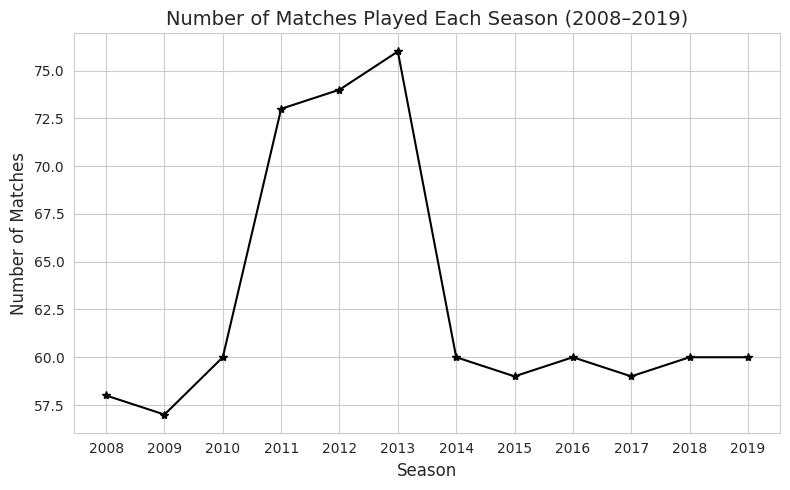

In [52]:
season_matches = matches['season'].value_counts().sort_index()
plt.figure(figsize=(8,5))
plt.plot(season_matches.index,
season_matches.values,
marker='*',
linestyle='-',color='k')
plt.title("Number of Matches Played Each Season (2008–2019)")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.xticks(season_matches.index)
plt.tight_layout()
plt.show()

**Insights-**

* The highest number of matches was recorded in 2013, with approximately 76 matches.
* A significant increase in matches occurred between 2011 and 2013 due to the expansion of teams in the league.
* The number of matches held in each season after the tear 2013 is constant around 55-60.
* This shows the significant trend over the craze in IPL matches and it's importance.







**Q.9**Top 10 players based on no. of Man of Match (MOM) awards won.

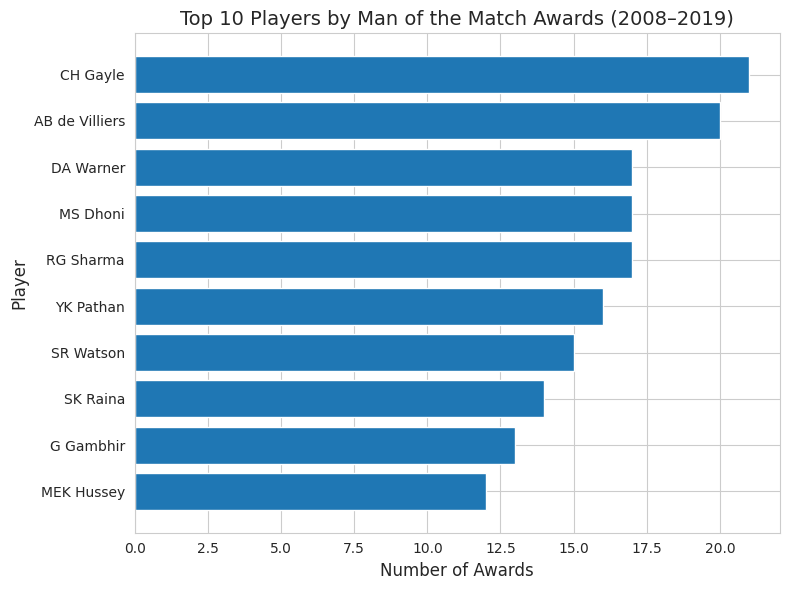

In [53]:
mom_counts = matches['player_of_match'].value_counts().head(10)
plt.figure(figsize=(8,6))
plt.barh(mom_counts.index,
mom_counts.values)
plt.title("Top 10 Players by Man of the Match Awards (2008–2019)")
plt.xlabel("Number of Awards")
plt.ylabel("Player")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Insights-**

* Frequent MOM awards indicate strong influence on match outcomes and team success.
* Chris Gayle has received the highest number of Man of the Match awards between 2008 and 2019.
*  AB de Villiers closely follows, demonstrating consistent match-winning
performances.
* Players like MS Dhoni, Rohit Sharma, and David Warner also show significant individual impact.





**Q.10** Does winning the toss mean winning the match?

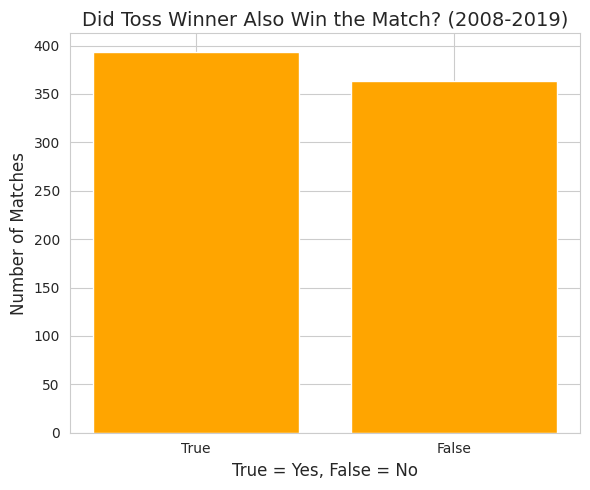

In [54]:
matches['toss_match_win'] = matches['toss_winner'] == matches['winner']
toss_result = matches['toss_match_win'].value_counts()
plt.figure(figsize=(6,5))
plt.bar(toss_result.index.astype(str),
toss_result.values,color='orange')
plt.title("Did Toss Winner Also Win the Match? (2008-2019)")
plt.xlabel("True = Yes, False = No")

plt.ylabel("Number of Matches")
plt.tight_layout()
plt.show()

**Insights-**

*  Winning the toss does not guarantee match victory.
*  Approximately 51.98% of matches were won by the team that also won the toss.
* Around 48.02% of matches were won by the team that lost the toss.
* The IPL remains highly competitive, with outcomes largely independent of toss advantage.








**Q.11**What was the decision taken by captains when they won the toss?

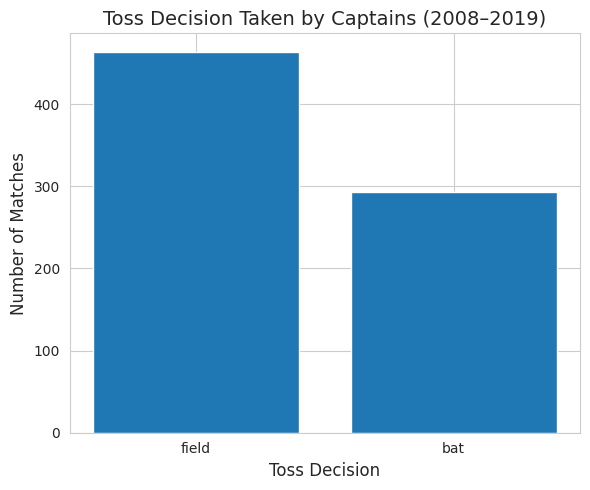

In [55]:
toss_decision_counts = matches['toss_decision'].value_counts()
plt.figure(figsize=(6,5))
plt.bar(toss_decision_counts.index,
toss_decision_counts.values)
plt.title("Toss Decision Taken by Captains (2008–2019)")
plt.xlabel("Toss Decision")
plt.ylabel("Number of Matches")
plt.tight_layout()
plt.show()

**Insight-**
*  Fielding was chosen significantly more often than batting first during 2008-2019.
*  The majority of captains preferred to field first after winning the toss.

*  The trend indicates that strategic planning plays an important role in toss decisions.
*  This preference suggests that teams favor chasing targets in T20 cricket.





**Q.12**No. of matches where D/L method was applied every season.

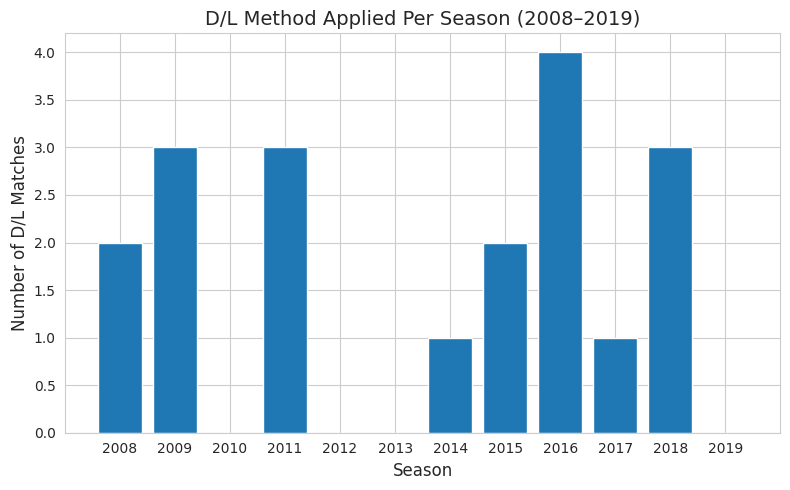

In [56]:
dl_season = matches.groupby('season')['dl_applied'].sum()
plt.figure(figsize=(8,5))
plt.bar(dl_season.index,
dl_season.values)
plt.title("D/L Method Applied Per Season (2008–2019)")
plt.xlabel("Season")
plt.ylabel("Number of D/L Matches")
plt.xticks(dl_season.index)
plt.tight_layout()
plt.show()

**Insights-**

*  The D/L method was applied in multiple seasons between 2008 and 2019.
*  Seasons like 2009, 2011, and 2018 also recorded multiple D/L applications.

*   Weather impact varied seasonally and was not consistent across all IPL years.
*  Overall, D/L-affected matches were relatively few compared to total matches played
each season.





**Q.13** Different results for matches.

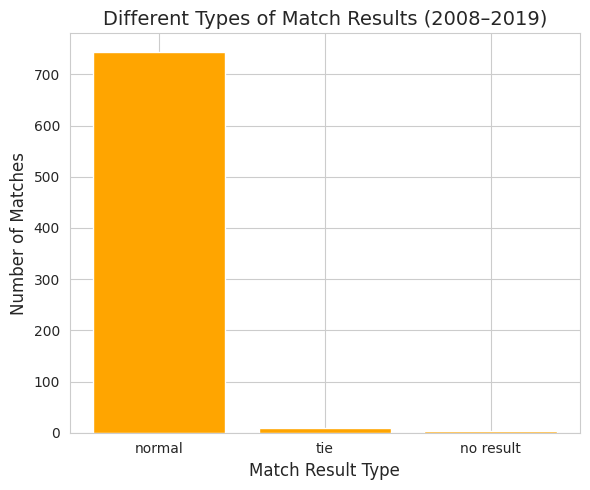

In [57]:
result_counts = matches['result'].value_counts()
plt.figure(figsize=(6,5))
plt.bar(result_counts.index,result_counts.values,color='orange')
plt.title("Different Types of Match Results (2008–2019)")
plt.xlabel("Match Result Type")
plt.ylabel("Number of Matches")
plt.tight_layout()
plt.show()

**Insights-**

*  Tie matches were very rare compared to normal outcomes.
*  Only a small number of matches resulted in no result, mainly due to weather interruptions.


*  Tie and no-result matches add unpredictability but represent a very small fraction of total IPL games.
*  The dominance of normal results indicates smooth tournament execution across seasons.
* The majority of IPL matches between 2008 and 2019 ended with a normal result.








**Q.14** How many times did a team win the toss?

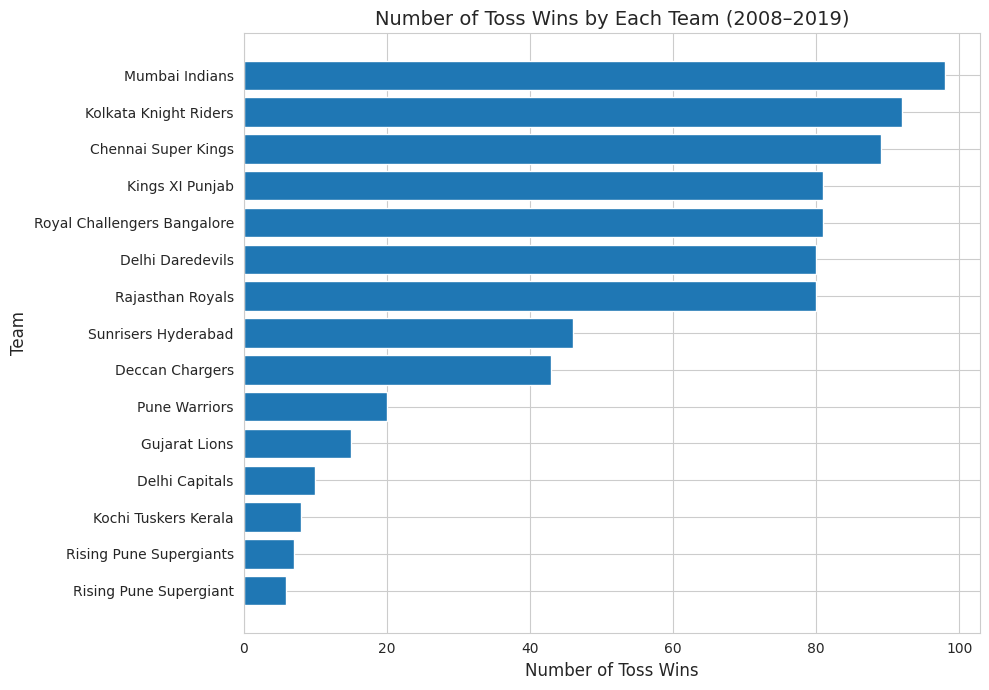

In [58]:
toss_wins = matches['toss_winner'].value_counts()
plt.figure(figsize=(10,7))
plt.barh(toss_wins.index,
toss_wins.values)
plt.title("Number of Toss Wins by Each Team (2008–2019)")
plt.xlabel("Number of Toss Wins")
plt.ylabel("Team")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Insights-**


* Kolkata Knight Riders and Chennai Super Kings also show a high number of toss wins.

* Mumbai Indians have won the toss the highest number of times between 2008 and 2019.
* Toss wins are relatively distributed among major franchises.
* Statistical analysis confirms that toss wins alone do not guarantee overall team dominance.




**Q.15** Best venue for defending and chasing a total.

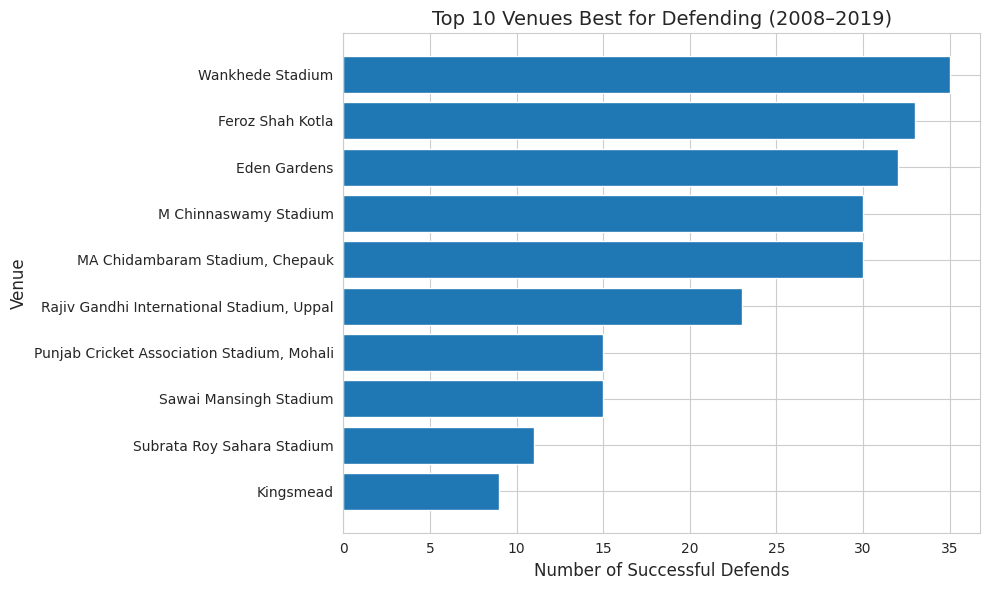

In [59]:
defend_matches = matches[matches['win_by_runs'] > 0]
best_defend_venue = defend_matches['venue'].value_counts()
plt.figure(figsize=(10,6))
plt.barh(best_defend_venue.head(10).index,
best_defend_venue.head(10).values)
plt.title("Top 10 Venues Best for Defending (2008–2019)")
plt.xlabel("Number of Successful Defends")
plt.ylabel("Venue")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Insights-**


*  Wankhede Stadium recorded the highest number of successful defenses between 2008 and 2019.
*  Teams batting first have historically performed well at these stadiums.
*  Venue characteristics significantly influence match strategy and toss decisions.
* These venues may provide pitch conditions favorable for bowlers during the second innings.



**Q.16** Best defending and chasing teams.

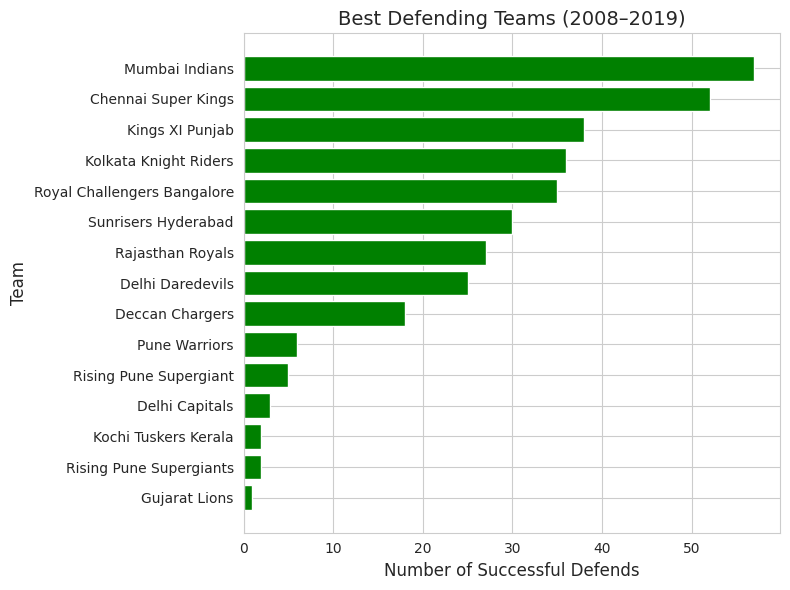

In [60]:
# Matches won by defending team
defend_matches = matches[matches['win_by_runs'] > 0]
best_defending_team = defend_matches['winner'].value_counts()
plt.figure(figsize=(8,6))
plt.barh(best_defending_team.index, best_defending_team.values,color='green')
plt.title("Best Defending Teams (2008–2019)")
plt.xlabel("Number of Successful Defends")
plt.ylabel("Team")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Insights-**
- Mumbai Indians have the highest number of successful defenses between 2008 and 2019.
- Successful defending requires strong bowling, especially in the death overs.
- Mumbai Indians dominance reflects their balanced squad and effective bowling strategies.
- Chennai Super Kings also show strong defending performance.


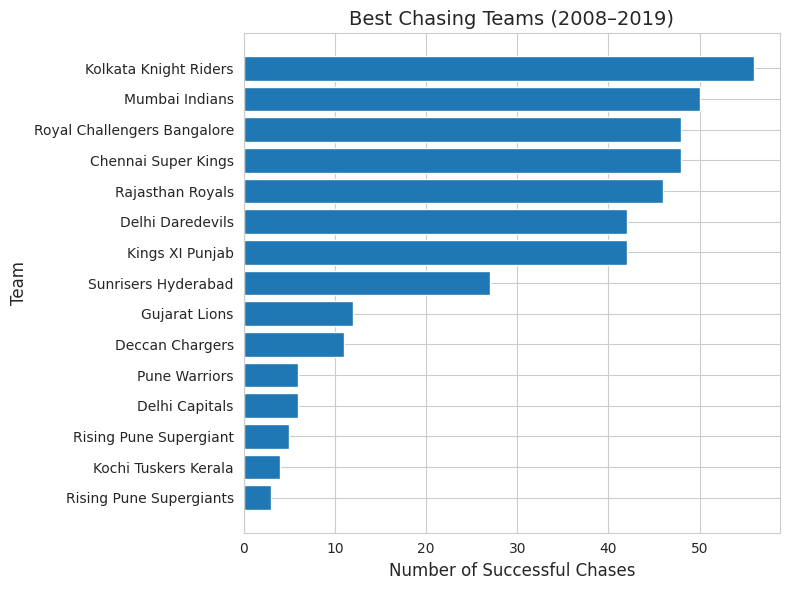

In [61]:
# Matches won by chasing team
chase_matches = matches[matches['win_by_wickets'] > 0]
best_chasing_team = chase_matches['winner'].value_counts()
plt.figure(figsize=(8,6))
plt.barh(best_chasing_team.index,
best_chasing_team.values)
plt.title("Best Chasing Teams (2008–2019)")
plt.xlabel("Number of Successful Chases")
plt.ylabel("Team")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Insights-**

*  Kolkata Knight Riders have the highest number of successful run chases.
* Successful chasing teams typically have stable top-order batting and strong finishers.

*  Teams that perform well in both defending and chasing demonstrate overall strategic strength.
*  Chasing performance reflects composure under pressure and batting depth.





**Q.17** No. of matches played in different stadiums.

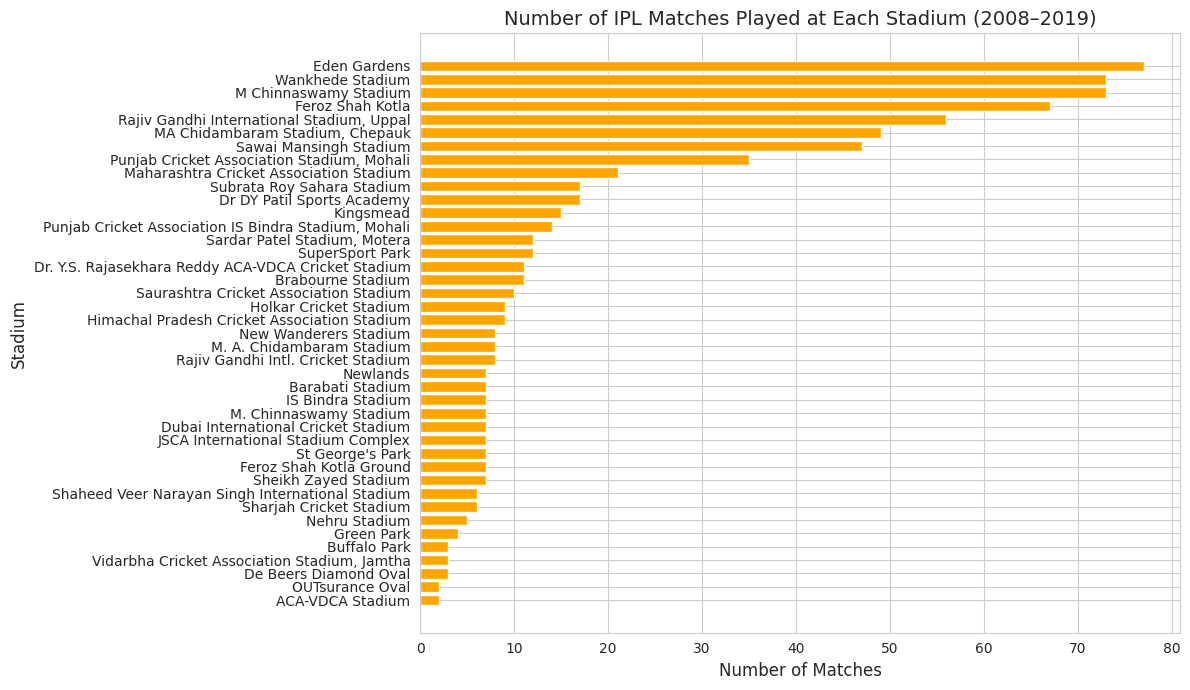

In [62]:
stadium_counts = matches['venue'].value_counts()
plt.figure(figsize=(12,7))
plt.barh(stadium_counts.index, stadium_counts.values, color='orange')
plt.title("Number of IPL Matches Played at Each Stadium (2008–2019)")
plt.xlabel("Number of Matches")
plt.ylabel("Stadium")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Insights-**
- Eden Gardens has hosted the highest number of IPL matches between 2008 and 2019.

- Wankhede Stadium and M. Chinnaswamy Stadium are also among the most
frequently used venues.

- Major metropolitan cities tend to host more matches due to better infrastructure and larger fan base.

-Some international and temporary venues (like UAE stadiums) hosted comparatively fewer matches.

- Established cricket centers consistently serve as primary IPL venues across seasons.



**Key Findings: Summary**


*  One major conclusion can be drawn from these datasets is that Mumbai Indians proved as the most hiking team between 2008-2019 in match winnning.
* Most of the captains prepared themselevs to field indicating the strategic advantage while chasing.
* One more thing that concluded was, winning or losing the toss did'nt determined their final outcomes.
* Winning was'nt predictable, it all depended upon the strategy and trend to play a match.
* As most of the matches were won by the team through their sudden setback and was not even expected to be won.
Even a single run made a huge changes in the match and the single missed out run/wicket too made the huge changes in the match outcome.










**Recommendations-**

1. Cities like Indore, Kanpur, Rajkot, Ranchi hosted very few matches.IPL should schedule schedule more matches in these cities to expand their fanbase.  
2. Low match counts often mean limited stadium infrastructure. IPL and BCCI should invest in upgrdaing stadiums in smaller cities.

1. Matches were held abroad during special seasons like 2009 Indians Premier League in South Africa. It should be hosted internationally too for global promotion or recognition.
2. Implementaion of rotational stadium hosting should take place instead of repeating the same venues every season.

1. New franchises should be introduces in cities with low match counts.






